<a href="https://colab.research.google.com/github/Sia0412/Flask-Mega/blob/main/IOT_ecosystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title dataset shape
import pandas as pd
import numpy as np
df = pd.read_csv("/content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv")
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (4000, 18)
Rows: 4000
Columns: 18


In [2]:
#@title column names
print(df.columns.tolist())

['Heart_Rate', 'Blood_Pressure', 'Blood_Oxygen_Level', 'Body_Temperature', 'Respiration_Rate', 'Glucose_Level', 'ECG_Signal_Intensity', 'Activity_Level', 'Sleep_Duration_Hours', 'Stress_Index', 'IoT_Device_Connectivity', 'EHR_Data_Completeness', 'Wearable_Device_Count', 'Daily_Steps', 'Healthcare_Network_Latency_ms', 'Cloud_Data_Transfer_Rate', 'Medical_Alert_Frequency', 'Patient_Health_Status']


In [3]:
#@title data types
df.dtypes

,0
Heart_Rate,int64
Blood_Pressure,int64
Blood_Oxygen_Level,float64
Body_Temperature,float64
Respiration_Rate,int64
Glucose_Level,int64
ECG_Signal_Intensity,float64
Activity_Level,int64
Sleep_Duration_Hours,float64
Stress_Index,int64


In [4]:
#@title missing values
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing_df

,Column,Missing Values
0,Heart_Rate,0
1,Blood_Pressure,0
2,Blood_Oxygen_Level,0
3,Body_Temperature,0
4,Respiration_Rate,0
5,Glucose_Level,0
6,ECG_Signal_Intensity,0
7,Activity_Level,0
8,Sleep_Duration_Hours,0
9,Stress_Index,0


In [5]:
#@title finding duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [6]:
#@title descriptive statistics
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Heart_Rate,4000.0,80.615250,27.307245,45.00,57.00000,78.000,99.00000,180.00
Blood_Pressure,4000.0,134.757000,47.428096,80.00,80.00000,131.000,184.00000,200.00
Blood_Oxygen_Level,4000.0,95.546110,4.579600,85.00,92.42750,96.740,100.00000,100.00
Body_Temperature,4000.0,36.520075,2.042645,34.00,34.74750,36.255,37.88000,41.00
Respiration_Rate,4000.0,18.101500,7.249161,8.00,12.00000,18.000,23.00000,40.00
Glucose_Level,4000.0,102.600750,41.788760,60.00,63.00000,93.000,127.00000,300.00
ECG_Signal_Intensity,4000.0,2.503020,1.437716,0.50,1.24475,2.413,3.63125,5.00
Activity_Level,4000.0,49.366750,33.483041,0.00,20.00000,50.000,77.00000,100.00
Sleep_Duration_Hours,4000.0,6.973878,2.825316,2.00,4.81750,6.980,9.08000,12.00
Stress_Index,4000.0,50.171250,34.237428,0.00,20.00000,50.000,80.00000,100.00


In [7]:
#@title target distribution
target = "Patient_Health_Status"

display(df[target].value_counts())

display(round(df[target].value_counts(normalize=True)*100,2))


,count
Patient_Health_Status,
Critical,1003
Moderate_Risk,1001
Stable,999
High_Risk,997


,proportion
Patient_Health_Status,
Critical,25.07
Moderate_Risk,25.02
Stable,24.98
High_Risk,24.92


In [8]:
#@title Feature Ranges
numeric_cols = df.select_dtypes(include=np.number).columns

ranges = pd.DataFrame({
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max(),
    "Range": df[numeric_cols].max()-df[numeric_cols].min()
})

display(ranges)

,Minimum,Maximum,Range
Heart_Rate,45.00,180.00,135.00
Blood_Pressure,80.00,200.00,120.00
Blood_Oxygen_Level,85.00,100.00,15.00
Body_Temperature,34.00,41.00,7.00
Respiration_Rate,8.00,40.00,32.00
Glucose_Level,60.00,300.00,240.00
ECG_Signal_Intensity,0.50,5.00,4.50
Activity_Level,0.00,100.00,100.00
Sleep_Duration_Hours,2.00,12.00,10.00
Stress_Index,0.00,100.00,100.00


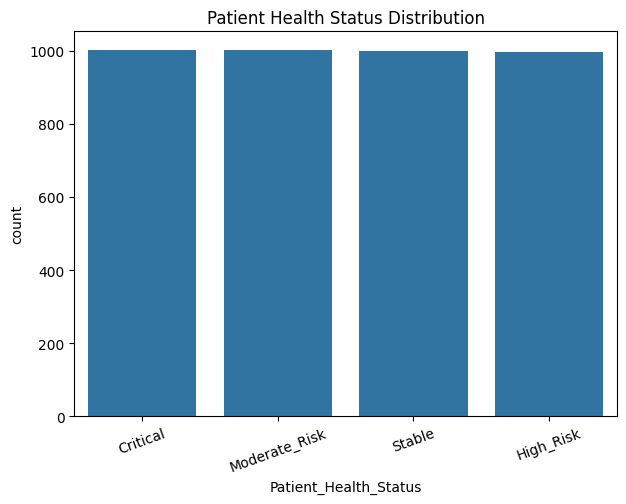

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Patient_Health_Status",
    order=df["Patient_Health_Status"].value_counts().index
)

plt.title("Patient Health Status Distribution")
plt.xticks(rotation=20)
plt.show()

In [10]:
#@title check target column (step-2)
target = "Patient_Health_Status"

if target in df.columns:
    print("Target column exists.")
else:
    print("Target column NOT found.")

Target column exists.


In [11]:
#@title class counts and percentage
print(df[target].value_counts())
print(round(df[target].value_counts(normalize=True)*100,2))

Patient_Health_Status
Critical         1003
Moderate_Risk    1001
Stable            999
High_Risk         997
Name: count, dtype: int64
Patient_Health_Status
Critical         25.07
Moderate_Risk    25.02
Stable           24.98
High_Risk        24.92
Name: proportion, dtype: float64


In [12]:
#@title Encode target labels
label_mapping = {
    "Stable": 0,
    "Moderate_Risk": 1,
    "High_Risk": 2,
    "Critical": 3
}

# Keep original labels for later interpretation
df["Patient_Health_Status_Label"] = df[target]

# Encode target
df[target] = df[target].map(label_mapping)

display(df[["Patient_Health_Status_Label",
            "Patient_Health_Status"]].head())

,Patient_Health_Status_Label,Patient_Health_Status
0,Stable,0
1,High_Risk,2
2,Stable,0
3,Moderate_Risk,1
4,Moderate_Risk,1


In [13]:
print(df[target].value_counts().sort_index())


Patient_Health_Status
0     999
1    1001
2     997
3    1003
Name: count, dtype: int64


In [14]:
#@title Prepare feature matrix and target vector
X = df.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label"
])

y = df["Patient_Health_Status"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4000, 17)
Target Shape: (4000,)


In [15]:
#@title step 3 (verify target column)
# Target column names

target = "Patient_Health_Status"
original_target = "Patient_Health_Status_Label"

print("Encoded Target Exists:",
      target in df.columns)

print("Original Target Exists:",
      original_target in df.columns)

Encoded Target Exists: True
Original Target Exists: True


In [16]:
print("Checking Feature Matrix...\n")

if target in X.columns:
    print("ERROR: Target column is inside X.")
else:
    print("PASS: Target column removed from X.")

if original_target in X.columns:
    print("ERROR: Original labels are inside X.")
else:
    print("PASS: Original labels removed from X.")

Checking Feature Matrix...

PASS: Target column removed from X.
PASS: Original labels removed from X.


In [17]:
#@title input feature checking
print("Input Features Used")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Input Features Used
1. Heart_Rate
2. Blood_Pressure
3. Blood_Oxygen_Level
4. Body_Temperature
5. Respiration_Rate
6. Glucose_Level
7. ECG_Signal_Intensity
8. Activity_Level
9. Sleep_Duration_Hours
10. Stress_Index
11. IoT_Device_Connectivity
12. EHR_Data_Completeness
13. Wearable_Device_Count
14. Daily_Steps
15. Healthcare_Network_Latency_ms
16. Cloud_Data_Transfer_Rate
17. Medical_Alert_Frequency


In [18]:
#@title check for suspicions
keywords = [
    "health_status",
    "target",
    "risk",
    "label",
    "class"
]

suspected = []

for column in X.columns:

    column_lower = column.lower()

    for word in keywords:

        if word in column_lower:
            suspected.append(column)
            break

if len(suspected)==0:
    print("No suspicious feature names found.")
else:
    print("Possible leakage features:")

    for feature in suspected:
        print(feature)

No suspicious feature names found.


In [19]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print()

if len(X)==len(y):
    print("PASS: X and y have the same number of samples.")
else:
    print("ERROR: Sample mismatch.")

Feature Matrix Shape : (4000, 17)
Target Shape : (4000,)

PASS: X and y have the same number of samples.


In [20]:
print(df[[
    "Patient_Health_Status_Label",
    "Patient_Health_Status"
]].head(10))

  Patient_Health_Status_Label  Patient_Health_Status
0                      Stable                      0
1                   High_Risk                      2
2                      Stable                      0
3               Moderate_Risk                      1
4               Moderate_Risk                      1
5                   High_Risk                      2
6                   High_Risk                      2
7                      Stable                      0
8               Moderate_Risk                      1
9                    Critical                      3


In [21]:
#@title final report to leakage
print("="*60)
print("STEP 3 COMPLETED")
print("="*60)

print("""
✓ Patient_Health_Status removed from X

✓ Original labels preserved

✓ No target-derived features created

✓ Dataset ready for Feature Engineering (Step 4)
""")

STEP 3 COMPLETED

✓ Patient_Health_Status removed from X

✓ Original labels preserved

✓ No target-derived features created

✓ Dataset ready for Feature Engineering (Step 4)



In [22]:
#@title step-4 (Epsilon defining)
df_fe = df.copy()

print("Feature Engineering Started...")
# Small value to avoid division by zero
epsilon = 1e-8

Feature Engineering Started...


In [23]:
#@title Physiological Interaction Features
df_fe["HR_BP_Interaction"] = (
    df_fe["Heart_Rate"] *
    df_fe["Blood_Pressure"]
)

df_fe["Oxygen_Respiration_Ratio"] = (
    df_fe["Blood_Oxygen_Level"] /
    (df_fe["Respiration_Rate"] + epsilon)
)

df_fe["Glucose_Stress_Interaction"] = (
    df_fe["Glucose_Level"] *
    df_fe["Stress_Index"]
)

df_fe["ECG_HR_Interaction"] = (
    df_fe["ECG_Signal_Intensity"] *
    df_fe["Heart_Rate"]
)

In [24]:
#@title Behavioral Interaction Features
df_fe["Activity_Sleep_Ratio"] = (
    df_fe["Activity_Level"] /
    (df_fe["Sleep_Duration_Hours"] + epsilon)
)

df_fe["Steps_per_Activity"] = (
    df_fe["Daily_Steps"] /
    (df_fe["Activity_Level"] + epsilon)
)

df_fe["Stress_Sleep_Interaction"] = (
    df_fe["Stress_Index"] *
    df_fe["Sleep_Duration_Hours"]
)

In [25]:
#@title IoT Interaction Features
df_fe["Connectivity_EHR_Product"] = (
    df_fe["IoT_Device_Connectivity"] *
    df_fe["EHR_Data_Completeness"]
)

df_fe["Wearable_Connectivity_Ratio"] = (
    df_fe["Wearable_Device_Count"] /
    (df_fe["IoT_Device_Connectivity"] + epsilon)
)

In [26]:
#@title Network Interaction Features
df_fe["Latency_Transfer_Ratio"] = (
    df_fe["Healthcare_Network_Latency_ms"] /
    (df_fe["Cloud_Data_Transfer_Rate"] + epsilon)
)

df_fe["Network_Load_Index"] = (
    df_fe["Healthcare_Network_Latency_ms"] *
    df_fe["Medical_Alert_Frequency"]
)

In [27]:
#@title verification
print("New Features Created:\n")

new_features = [
    "HR_BP_Interaction",
    "Oxygen_Respiration_Ratio",
    "Glucose_Stress_Interaction",
    "ECG_HR_Interaction",
    "Activity_Sleep_Ratio",
    "Steps_per_Activity",
    "Stress_Sleep_Interaction",
    "Connectivity_EHR_Product",
    "Wearable_Connectivity_Ratio",
    "Latency_Transfer_Ratio",
    "Network_Load_Index"
]

print(new_features)
display(df_fe[new_features].head())

New Features Created:

['HR_BP_Interaction', 'Oxygen_Respiration_Ratio', 'Glucose_Stress_Interaction', 'ECG_HR_Interaction', 'Activity_Sleep_Ratio', 'Steps_per_Activity', 'Stress_Sleep_Interaction', 'Connectivity_EHR_Product', 'Wearable_Connectivity_Ratio', 'Latency_Transfer_Ratio', 'Network_Load_Index']


,HR_BP_Interaction,Oxygen_Respiration_Ratio,Glucose_Stress_Interaction,ECG_HR_Interaction,Activity_Sleep_Ratio,Steps_per_Activity,Stress_Sleep_Interaction,Connectivity_EHR_Product,Wearable_Connectivity_Ratio,Latency_Transfer_Ratio,Network_Load_Index
0,7470,12.500000,8664,164.160,0.000000,1.385500e+12,516.80,5000,0.040000,2.640864,1976
1,9028,12.500000,3536,164.502,23.873874,7.201887e+01,57.72,3330,0.067568,0.141628,78
2,15200,5.882353,2068,105.108,1.362398,5.458000e+02,161.48,2964,0.038462,3.533054,194
3,4536,4.478571,4440,83.888,3.670635,1.704595e+02,745.92,8500,0.050000,1.326655,196
4,21800,5.697059,0,54.500,0.000000,9.933000e+11,0.00,2500,0.200000,3.295993,459


In [28]:
print("Original Dataset Shape :", df.shape)
print("New Dataset Shape      :", df_fe.shape)

Original Dataset Shape : (4000, 19)
New Dataset Shape      : (4000, 30)


In [29]:
print(df_fe[new_features].isnull().sum())

HR_BP_Interaction              0
Oxygen_Respiration_Ratio       0
Glucose_Stress_Interaction     0
ECG_HR_Interaction             0
Activity_Sleep_Ratio           0
Steps_per_Activity             0
Stress_Sleep_Interaction       0
Connectivity_EHR_Product       0
Wearable_Connectivity_Ratio    0
Latency_Transfer_Ratio         0
Network_Load_Index             0
dtype: int64


In [30]:
df_fe.to_csv("feature_engineered_healthcare_dataset.csv", index=False)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


In [31]:
#@title step-5 (Selection of Numerical Features)
from scipy.stats import skew
# Select only numerical columns
numerical_features = df_fe.select_dtypes(include=np.number).columns.tolist()

# Remove target column if encoded
if "Patient_Health_Status" in numerical_features:
    numerical_features.remove("Patient_Health_Status")

print("Number of Numerical Features:", len(numerical_features))

Number of Numerical Features: 28


In [32]:
#@title Calculate Statistics
results = []

for feature in numerical_features:

    values = df_fe[feature]

    mean_value = values.mean()
    std_value = values.std()

    minimum = values.min()
    maximum = values.max()

    median = values.median()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    # Coefficient of Variation
    if mean_value != 0:
        cv = std_value / mean_value
    else:
        cv = np.nan

    # Skewness
    skewness = values.skew()

    # Outlier Percentage (IQR Method)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((values < lower) | (values > upper)).sum()

    outlier_percentage = (outliers / len(values)) * 100

    results.append([
        feature,
        mean_value,
        std_value,
        minimum,
        maximum,
        median,
        iqr,
        cv,
        skewness,
        outlier_percentage
    ])

In [33]:
#@title create analysis table
analysis_df = pd.DataFrame(results, columns=[
    "Feature",
    "Mean",
    "Std",
    "Minimum",
    "Maximum",
    "Median",
    "IQR",
    "Coefficient_of_Variation",
    "Skewness",
    "Outlier_Percentage"
])

display(analysis_df)

,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage
0,Heart_Rate,8.061525e+01,2.730725e+01,45.000000,1.800000e+02,78.000000,42.000000,0.338735,0.505786,0.375
1,Blood_Pressure,1.347570e+02,4.742810e+01,80.000000,2.000000e+02,131.000000,104.000000,0.351953,0.153022,0.000
2,Blood_Oxygen_Level,9.554611e+01,4.579600e+00,85.000000,1.000000e+02,96.740000,7.572500,0.047931,-0.775692,0.000
3,Body_Temperature,3.652007e+01,2.042645e+00,34.000000,4.100000e+01,36.255000,3.132500,0.055932,0.534406,0.000
4,Respiration_Rate,1.810150e+01,7.249161e+00,8.000000,4.000000e+01,18.000000,11.000000,0.400473,0.366283,0.200
5,Glucose_Level,1.026008e+02,4.178876e+01,60.000000,3.000000e+02,93.000000,64.000000,0.407295,1.015809,1.050
6,ECG_Signal_Intensity,2.503020e+00,1.437716e+00,0.500000,5.000000e+00,2.413000,2.386500,0.574393,0.217042,0.000
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000
8,Sleep_Duration_Hours,6.973878e+00,2.825316e+00,2.000000,1.200000e+01,6.980000,4.262500,0.405128,0.013022,0.000
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000


In [34]:
#@title Feature Classification
def classify_feature(mean_value, cv):

    if cv < 0.10:

        if mean_value >= 75:
            return "Consistently High"

        elif mean_value <= 25:
            return "Consistently Low"

        else:
            return "Stable"

    else:
        return "Highly Variable"

In [35]:
#@title Apply Classification
analysis_df["Consistency"] = analysis_df.apply(

    lambda row: classify_feature(
        row["Mean"],
        row["Coefficient_of_Variation"]
    ),

    axis=1
)

display(analysis_df)

,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage,Consistency
0,Heart_Rate,8.061525e+01,2.730725e+01,45.000000,1.800000e+02,78.000000,42.000000,0.338735,0.505786,0.375,Highly Variable
1,Blood_Pressure,1.347570e+02,4.742810e+01,80.000000,2.000000e+02,131.000000,104.000000,0.351953,0.153022,0.000,Highly Variable
2,Blood_Oxygen_Level,9.554611e+01,4.579600e+00,85.000000,1.000000e+02,96.740000,7.572500,0.047931,-0.775692,0.000,Consistently High
3,Body_Temperature,3.652007e+01,2.042645e+00,34.000000,4.100000e+01,36.255000,3.132500,0.055932,0.534406,0.000,Stable
4,Respiration_Rate,1.810150e+01,7.249161e+00,8.000000,4.000000e+01,18.000000,11.000000,0.400473,0.366283,0.200,Highly Variable
5,Glucose_Level,1.026008e+02,4.178876e+01,60.000000,3.000000e+02,93.000000,64.000000,0.407295,1.015809,1.050,Highly Variable
6,ECG_Signal_Intensity,2.503020e+00,1.437716e+00,0.500000,5.000000e+00,2.413000,2.386500,0.574393,0.217042,0.000,Highly Variable
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000,Highly Variable
8,Sleep_Duration_Hours,6.973878e+00,2.825316e+00,2.000000,1.200000e+01,6.980000,4.262500,0.405128,0.013022,0.000,Highly Variable
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000,Highly Variable


In [36]:
analysis_df = analysis_df.sort_values(
    by="Coefficient_of_Variation",
    ascending=False
)

display(analysis_df)

,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage,Consistency
22,Steps_per_Activity,1.249719e+11,3.698707e+11,10.180000,1.798800e+12,192.058608,389.489682,2.959631,3.052408,17.375,Highly Variable
26,Latency_Transfer_Ratio,3.920307e+00,5.061374e+00,0.052154,4.675835e+01,2.373835,3.078891,1.291066,3.476254,10.000,Highly Variable
21,Activity_Sleep_Ratio,9.019705e+00,8.988270e+00,0.000000,5.000000e+01,7.000000,9.366169,0.996515,1.913544,5.325,Highly Variable
27,Network_Load_Index,8.797057e+02,8.077891e+02,0.000000,3.486000e+03,640.000000,1120.500000,0.918249,1.008756,1.350,Highly Variable
19,Glucose_Stress_Interaction,5.297984e+03,4.686168e+03,0.000000,3.000000e+04,4354.000000,5760.000000,0.884519,1.285272,3.400,Highly Variable
23,Stress_Sleep_Interaction,3.856452e+02,3.348230e+02,0.000000,1.200000e+03,308.980000,500.000000,0.868215,0.742965,0.000,Highly Variable
25,Wearable_Connectivity_Ratio,4.964879e-02,4.272878e-02,0.010000,2.500000e-01,0.040000,0.034674,0.860621,2.406833,7.775,Highly Variable
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000,Highly Variable
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000,Highly Variable
20,ECG_HR_Interaction,1.992726e+02,1.319911e+02,22.500000,7.631660e+02,180.071000,190.614500,0.662364,0.798588,1.100,Highly Variable


In [37]:
analysis_df.to_csv(
    "Step5_HighLow_Consistency_Analysis.csv",
    index=False
)

print("Step 5 analysis saved successfully.")

Step 5 analysis saved successfully.


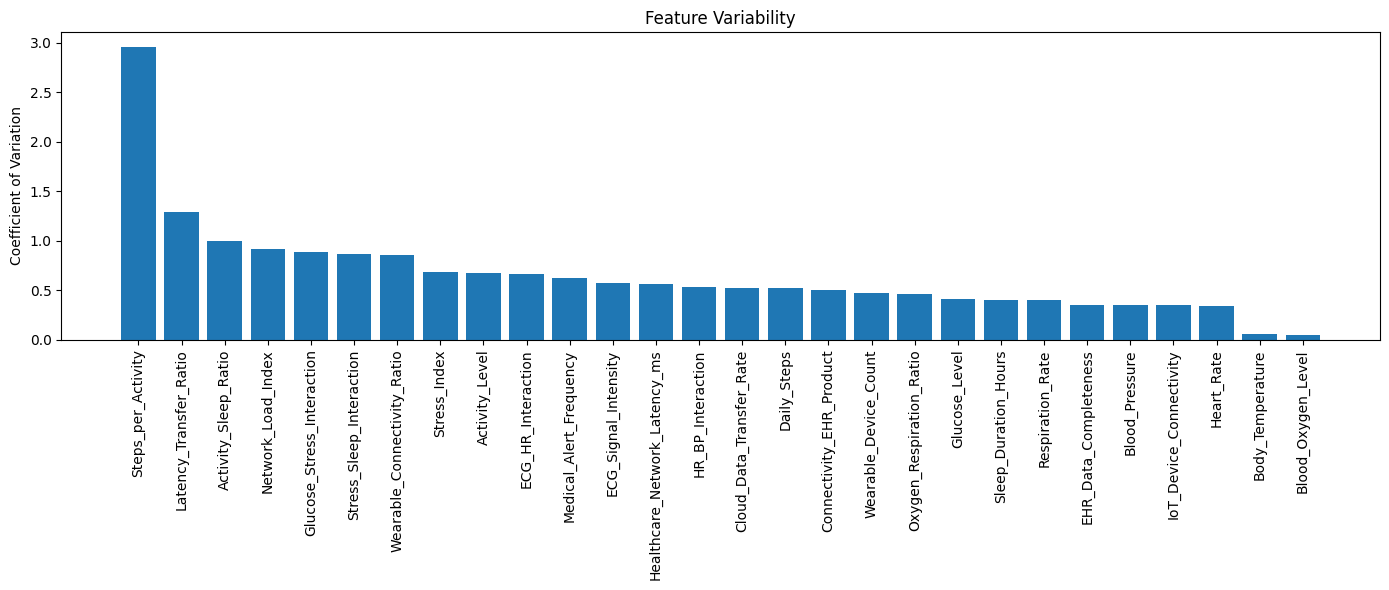

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    analysis_df["Feature"],
    analysis_df["Coefficient_of_Variation"]
)

plt.xticks(rotation=90)

plt.ylabel("Coefficient of Variation")

plt.title("Feature Variability")

plt.tight_layout()

plt.show()

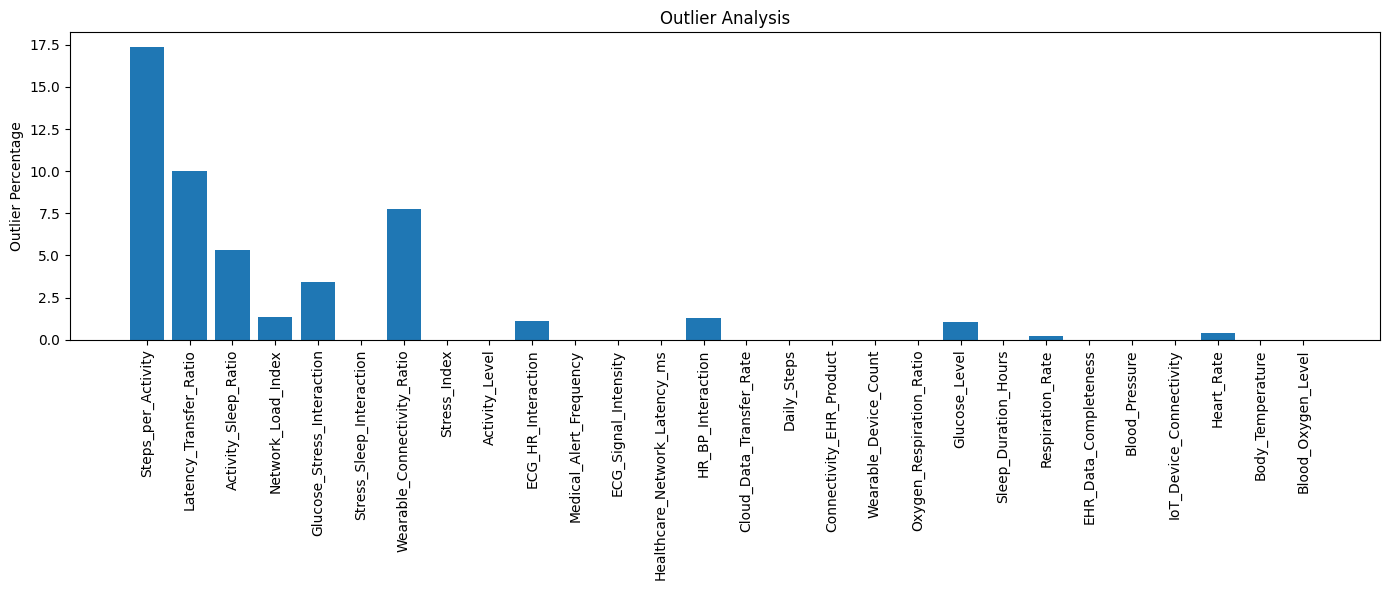

In [39]:
plt.figure(figsize=(14,6))

plt.bar(
    analysis_df["Feature"],
    analysis_df["Outlier_Percentage"]
)

plt.xticks(rotation=90)

plt.ylabel("Outlier Percentage")

plt.title("Outlier Analysis")

plt.tight_layout()

plt.show()

In [40]:
#@title step-6 (activity-aware analysis)
import seaborn as sns

plt.style.use("default")

In [41]:
activity_features = [
    "Activity_Level",
    "Daily_Steps",
    "Sleep_Duration_Hours",
    "Stress_Index"
]

In [42]:
import seaborn as sns

plt.style.use("default")
#@title Create Activity–Health Profile Table
activity_profile = (
    df_fe
    .groupby("Patient_Health_Status_Label")[activity_features]
    .agg(["mean","std","median","min","max"])
)

display(activity_profile)

Activity_Level                             \
                                      mean        std median min  max   
Patient_Health_Status_Label                                             
Critical                         52.765703  33.937831   54.0   0  100   
High_Risk                        54.373119  33.959331   58.0   0  100   
Moderate_Risk                    53.430569  32.793344   56.0   0  100   
Stable                           36.885886  29.971680   33.0   0  100   

                             Daily_Steps                                     \
                                    mean          std   median   min    max   
Patient_Health_Status_Label                                                   
Critical                     9401.960120  4953.522565   9488.0  1001  17999   
High_Risk                    9459.398195  5013.877407   9501.0  1018  17999   
Moderate_Risk                9214.855145  4917.474694   8966.0  1028  17980   
Stable                       9935.816817  4839.375256  10088.0  1053  17999   

                            Sleep_Duration_Hours                              \
                                            mean       std median  min   max   
Patient_Health_Status_Label                                                    
Critical                                5.689442  2.595615   5.57  2.0  12.0   
High_Risk                               6.871294  2.681235   6.77  2.0  12.0   
Moderate_Risk                           6.998092  2.866011   7.12  2.0  12.0   
Stable                                  8.341572  2.504935   8.48  2.0  12.0   

                            Stress_Index                             
                                    mean        std median min  max  
Patient_Health_Status_Label                                          
Critical                       38.897308  31.321914   35.0   0  100  
High_Risk                      60.202608  33.492268   65.0   0  100  
Moderate_Risk                  43.475524  33.347438   41.0   0  100  
Stable                         58.188188  33.774251   60.0   0  100

In [43]:
activity_profile.to_csv(
    "Activity_Health_Profile.csv"
)

print("Activity profile table saved.")

Activity profile table saved.


In [44]:
#@title Mean Activity Table
mean_profile = (
    df_fe
    .groupby("Patient_Health_Status_Label")[activity_features]
    .mean()
)

display(mean_profile)

,Activity_Level,Daily_Steps,Sleep_Duration_Hours,Stress_Index
Patient_Health_Status_Label,,,,
Critical,52.765703,9401.960120,5.689442,38.897308
High_Risk,54.373119,9459.398195,6.871294,60.202608
Moderate_Risk,53.430569,9214.855145,6.998092,43.475524
Stable,36.885886,9935.816817,8.341572,58.188188


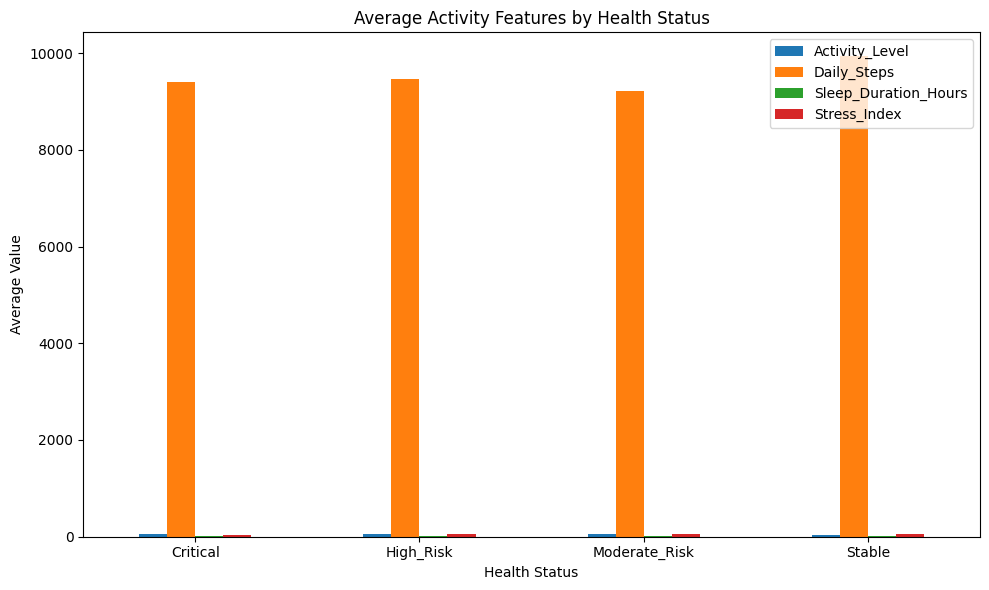

In [45]:
mean_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Activity Features by Health Status")

plt.ylabel("Average Value")

plt.xlabel("Health Status")

plt.xticks(rotation=0)

plt.legend(loc="best")

plt.tight_layout()

plt.show()

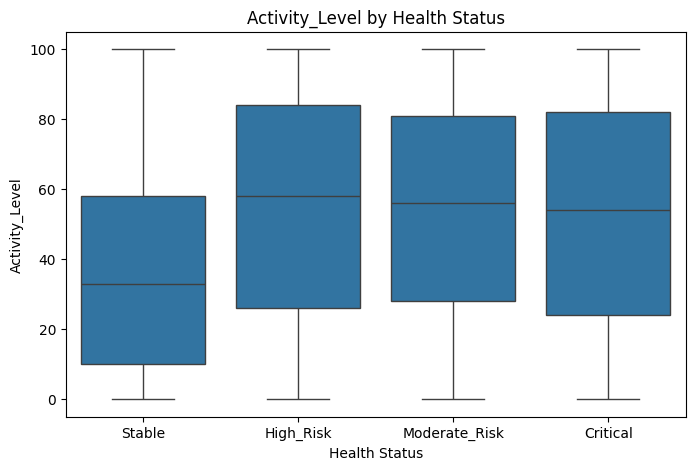

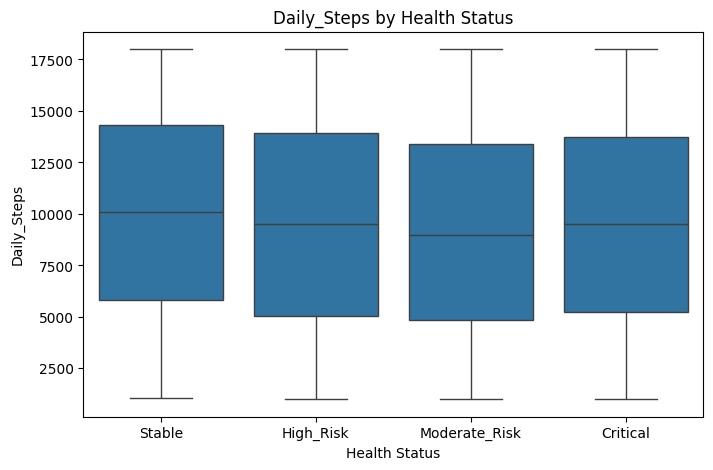

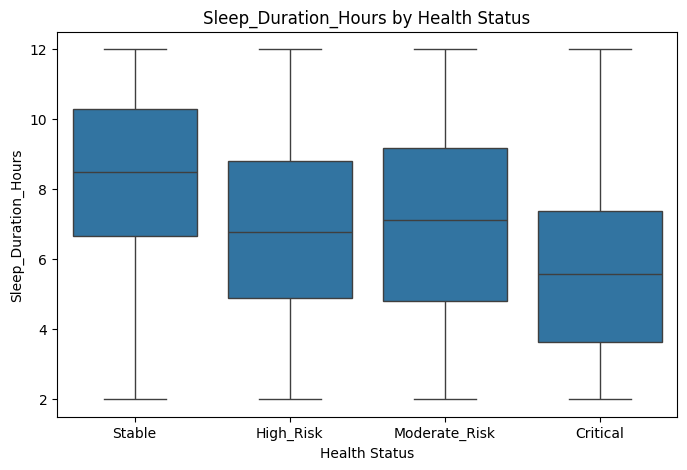

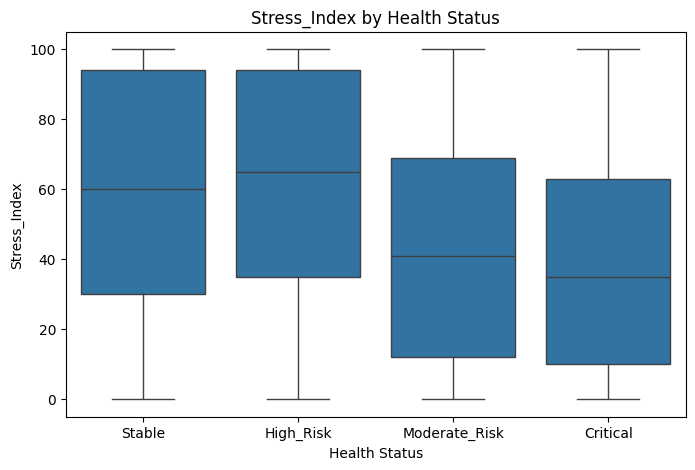

In [46]:
for feature in activity_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_fe,
        x="Patient_Health_Status_Label",
        y=feature
    )

    plt.title(f"{feature} by Health Status")

    plt.xlabel("Health Status")

    plt.ylabel(feature)

    plt.show()

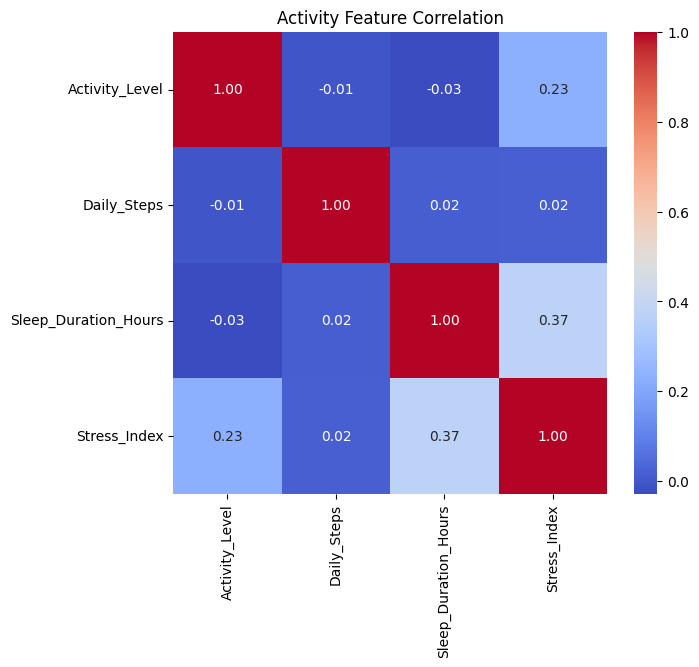

In [47]:
#@title Correlation Heatmap
plt.figure(figsize=(7,6))

corr = df_fe[activity_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Activity Feature Correlation")

plt.show()

In [48]:
summary = (
    df_fe
    .groupby("Patient_Health_Status_Label")[activity_features]
    .describe()
)

display(summary)

Activity_Level                                   \
                                     count       mean        std  min   25%   
Patient_Health_Status_Label                                                   
Critical                            1003.0  52.765703  33.937831  0.0  24.0   
High_Risk                            997.0  54.373119  33.959331  0.0  26.0   
Moderate_Risk                       1001.0  53.430569  32.793344  0.0  28.0   
Stable                               999.0  36.885886  29.971680  0.0  10.0   

                                               Daily_Steps               ...  \
                              50%   75%    max       count         mean  ...   
Patient_Health_Status_Label                                              ...   
Critical                     54.0  82.0  100.0      1003.0  9401.960120  ...   
High_Risk                    58.0  84.0  100.0       997.0  9459.398195  ...   
Moderate_Risk                56.0  81.0  100.0      1001.0  9214.855145  ...   
Stable                       33.0  58.0  100.0       999.0  9935.816817  ...   

                            Sleep_Duration_Hours       Stress_Index  \
                                             75%   max        count   
Patient_Health_Status_Label                                           
Critical                                    7.37  12.0       1003.0   
High_Risk                                   8.79  12.0        997.0   
Moderate_Risk                               9.18  12.0       1001.0   
Stable                                     10.29  12.0        999.0   

                                                                          \
                                  mean        std  min   25%   50%   75%   
Patient_Health_Status_Label                                                
Critical                     38.897308  31.321914  0.0  10.0  35.0  63.0   
High_Risk                    60.202608  33.492268  0.0  35.0  65.0  94.0   
Moderate_Risk                43.475524  33.347438  0.0  12.0  41.0  69.0   
Stable                       58.188188  33.774251  0.0  30.0  60.0  94.0   

                                    
                               max  
Patient_Health_Status_Label         
Critical                     100.0  
High_Risk                    100.0  
Moderate_Risk                100.0  
Stable                       100.0  

[4 rows x 32 columns]

In [49]:
#@title Interpret High-Risk Trends
print("="*60)
print("Activity-Aware Analysis Summary")
print("="*60)

for feature in activity_features:

    print(f"\nFeature: {feature}")

    means = (
        df_fe
        .groupby("Patient_Health_Status_Label")[feature]
        .mean()
    )

    print(means)

Activity-Aware Analysis Summary

Feature: Activity_Level
Patient_Health_Status_Label
Critical         52.765703
High_Risk        54.373119
Moderate_Risk    53.430569
Stable           36.885886
Name: Activity_Level, dtype: float64

Feature: Daily_Steps
Patient_Health_Status_Label
Critical         9401.960120
High_Risk        9459.398195
Moderate_Risk    9214.855145
Stable           9935.816817
Name: Daily_Steps, dtype: float64

Feature: Sleep_Duration_Hours
Patient_Health_Status_Label
Critical         5.689442
High_Risk        6.871294
Moderate_Risk    6.998092
Stable           8.341572
Name: Sleep_Duration_Hours, dtype: float64

Feature: Stress_Index
Patient_Health_Status_Label
Critical         38.897308
High_Risk        60.202608
Moderate_Risk    43.475524
Stable           58.188188
Name: Stress_Index, dtype: float64


In [50]:
summary.to_csv(
    "Step6_ActivityAware_Analysis.csv"
)

print("Step 6 completed successfully.")

Step 6 completed successfully.


In [51]:
#@title step 7 (restore original health label)
plt.style.use("default")
label_map = {
    0: "Stable",
    1: "Moderate_Risk",
    2: "High_Risk",
    3: "Critical"
}

if df_fe["Patient_Health_Status"].dtype != "object":
    df_fe["Health_Status"] = df_fe["Patient_Health_Status"].map(label_map)
else:
    df_fe["Health_Status"] = df_fe["Patient_Health_Status"]

In [52]:
#@title IoT and Network Features
iot_features = [

    "IoT_Device_Connectivity",

    "Wearable_Device_Count",

    "EHR_Data_Completeness",

    "Healthcare_Network_Latency_ms",

    "Cloud_Data_Transfer_Rate",

    "Medical_Alert_Frequency"

]

In [53]:
#@title IoT-System & Network Profile Table
iot_profile = (

    df_fe

    .groupby("Health_Status")[iot_features]

    .agg(["mean","std","median","min","max"])

)

display(iot_profile)

IoT_Device_Connectivity                             \
                                 mean        std median min  max   
Health_Status                                                      
Critical                    82.654038  23.336618   96.0  20  100   
High_Risk                   81.462387  23.834853   94.0  20  100   
Moderate_Risk               68.747253  27.292912   71.0  20  100   
Stable                      69.614615  26.619538   72.0  20  100   

              Wearable_Device_Count                           ...  \
                               mean       std median min max  ...   
Health_Status                                                 ...   
Critical                   3.023928  1.412599    3.0   1   5  ...   
High_Risk                  2.949850  1.426053    3.0   1   5  ...   
Moderate_Risk              2.993007  1.418785    3.0   1   5  ...   
Stable                     3.042042  1.448596    3.0   1   5  ...   

              Cloud_Data_Transfer_Rate                                 \
                                  mean        std median   min    max   
Health_Status                                                           
Critical                     52.882213  27.538030  51.79  5.02  99.83   
High_Risk                    52.875807  27.688980  53.59  5.09  99.97   
Moderate_Risk                51.870310  27.460451  51.72  5.01  99.88   
Stable                       52.946727  26.811060  52.14  5.01  99.95   

              Medical_Alert_Frequency                           
                                 mean       std median min max  
Health_Status                                                   
Critical                     7.162512  4.305049    7.0   0  14  
High_Risk                    6.853561  4.425943    7.0   0  14  
Moderate_Risk                6.988012  4.318548    7.0   0  14  
Stable                       6.933934  4.378811    7.0   0  14  

[4 rows x 30 columns]

In [54]:
iot_profile.to_csv(
    "Step7_IoT_System_Profile.csv"
)

print("IoT-System profile saved.")

IoT-System profile saved.


In [55]:
#@title Mean Comparison Table
mean_iot = (

    df_fe

    .groupby("Health_Status")[iot_features]

    .mean()

)

display(mean_iot)

,IoT_Device_Connectivity,Wearable_Device_Count,EHR_Data_Completeness,Healthcare_Network_Latency_ms,Cloud_Data_Transfer_Rate,Medical_Alert_Frequency
Health_Status,,,,,,
Critical,82.654038,3.023928,62.868395,125.768694,52.882213,7.162512
High_Risk,81.462387,2.949850,62.807422,124.401204,52.875807,6.853561
Moderate_Risk,68.747253,2.993007,85.110889,126.339660,51.870310,6.988012
Stable,69.614615,3.042042,61.695696,126.199199,52.946727,6.933934


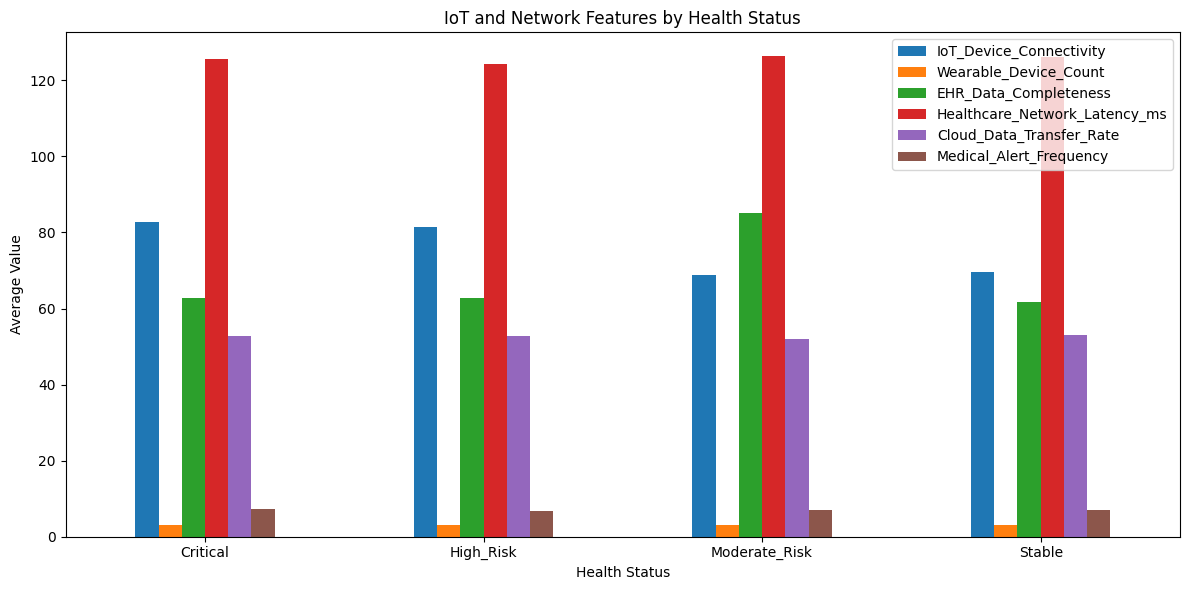

In [56]:
mean_iot.plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("IoT and Network Features by Health Status")

plt.xlabel("Health Status")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

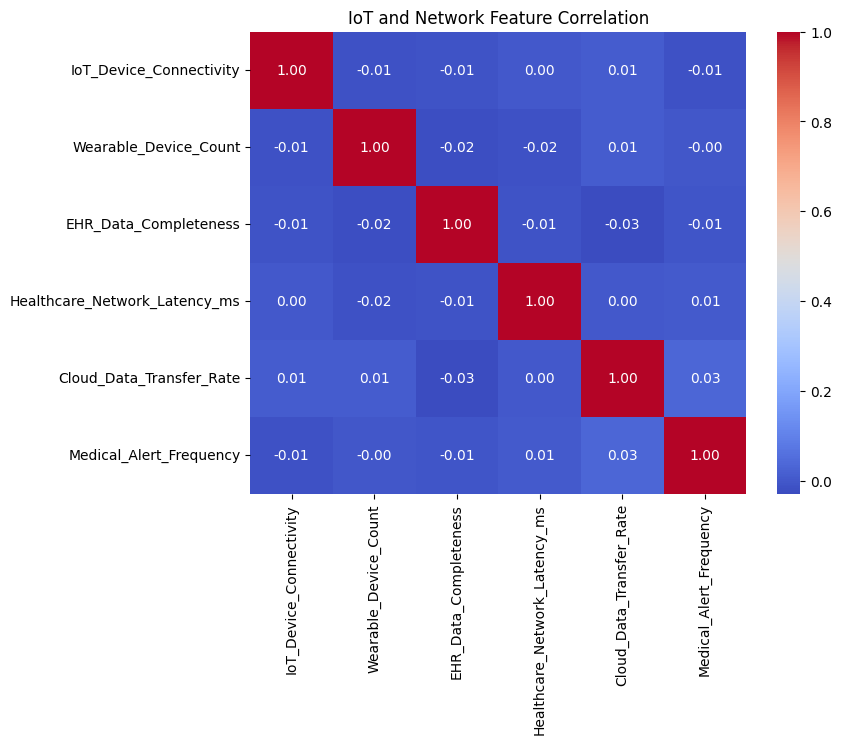

In [57]:
#@title Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df_fe[iot_features].corr()

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("IoT and Network Feature Correlation")

plt.show()

In [58]:
summary = (

    df_fe

    .groupby("Health_Status")[iot_features]

    .describe()

)

display(summary)

IoT_Device_Connectivity                                          \
                                count       mean        std   min   25%   50%   
Health_Status                                                                   
Critical                       1003.0  82.654038  23.336618  20.0  69.0  96.0   
High_Risk                       997.0  81.462387  23.834853  20.0  68.0  94.0   
Moderate_Risk                  1001.0  68.747253  27.292912  20.0  47.0  71.0   
Stable                          999.0  69.614615  26.619538  20.0  50.0  72.0   

                            Wearable_Device_Count            ...  \
                 75%    max                 count      mean  ...   
Health_Status                                                ...   
Critical       100.0  100.0                1003.0  3.023928  ...   
High_Risk      100.0  100.0                 997.0  2.949850  ...   
Moderate_Risk  100.0  100.0                1001.0  2.993007  ...   
Stable          99.0  100.0                 999.0  3.042042  ...   

              Cloud_Data_Transfer_Rate        Medical_Alert_Frequency  \
                                   75%    max                   count   
Health_Status                                                           
Critical                        77.405  99.83                  1003.0   
High_Risk                       76.960  99.97                   997.0   
Moderate_Risk                   76.250  99.88                  1001.0   
Stable                          76.215  99.95                   999.0   

                                                              
                   mean       std  min  25%  50%   75%   max  
Health_Status                                                 
Critical       7.162512  4.305049  0.0  4.0  7.0  11.0  14.0  
High_Risk      6.853561  4.425943  0.0  3.0  7.0  11.0  14.0  
Moderate_Risk  6.988012  4.318548  0.0  3.0  7.0  11.0  14.0  
Stable         6.933934  4.378811  0.0  3.0  7.0  11.0  14.0  

[4 rows x 48 columns]

In [59]:
#@title Monitoring Responsiveness Analysis
print("="*70)
print("Monitoring Responsiveness Analysis")
print("="*70)

latency = (

    df_fe

    .groupby("Health_Status")["Healthcare_Network_Latency_ms"]

    .mean()

)

transfer = (

    df_fe

    .groupby("Health_Status")["Cloud_Data_Transfer_Rate"]

    .mean()

)

print("\nAverage Network Latency (ms)")
print(latency)

print("\nAverage Cloud Data Transfer Rate")
print(transfer)

print("""
NOTE:

Healthcare_Network_Latency_ms and Cloud_Data_Transfer_Rate
are interpreted as proxy indicators of monitoring
responsiveness only.

They DO NOT represent actual collection-to-transmission
delay because the dataset has no timestamp information.
""")

Monitoring Responsiveness Analysis

Average Network Latency (ms)
Health_Status
Critical         125.768694
High_Risk        124.401204
Moderate_Risk    126.339660
Stable           126.199199
Name: Healthcare_Network_Latency_ms, dtype: float64

Average Cloud Data Transfer Rate
Health_Status
Critical         52.882213
High_Risk        52.875807
Moderate_Risk    51.870310
Stable           52.946727
Name: Cloud_Data_Transfer_Rate, dtype: float64

NOTE:

Healthcare_Network_Latency_ms and Cloud_Data_Transfer_Rate
are interpreted as proxy indicators of monitoring
responsiveness only.

They DO NOT represent actual collection-to-transmission
delay because the dataset has no timestamp information.



In [60]:
#@title Medical Alert Analysis
alerts = (

    df_fe

    .groupby("Health_Status")["Medical_Alert_Frequency"]

    .agg(["mean","std","min","max"])

)

display(alerts)

,mean,std,min,max
Health_Status,,,,
Critical,7.162512,4.305049,0,14
High_Risk,6.853561,4.425943,0,14
Moderate_Risk,6.988012,4.318548,0,14
Stable,6.933934,4.378811,0,14


In [61]:
#@title Connectivity Analysis
connectivity = (

    df_fe

    .groupby("Health_Status")[

        [

        "IoT_Device_Connectivity",

        "Wearable_Device_Count",

        "EHR_Data_Completeness"

        ]

    ]

    .mean()

)

display(connectivity)

,IoT_Device_Connectivity,Wearable_Device_Count,EHR_Data_Completeness
Health_Status,,,
Critical,82.654038,3.023928,62.868395
High_Risk,81.462387,2.949850,62.807422
Moderate_Risk,68.747253,2.993007,85.110889
Stable,69.614615,3.042042,61.695696


In [62]:
#@title Radar-Style Comparison Table
comparison = mean_iot.round(2)

display(comparison)

,IoT_Device_Connectivity,Wearable_Device_Count,EHR_Data_Completeness,Healthcare_Network_Latency_ms,Cloud_Data_Transfer_Rate,Medical_Alert_Frequency
Health_Status,,,,,,
Critical,82.65,3.02,62.87,125.77,52.88,7.16
High_Risk,81.46,2.95,62.81,124.40,52.88,6.85
Moderate_Risk,68.75,2.99,85.11,126.34,51.87,6.99
Stable,69.61,3.04,61.70,126.20,52.95,6.93


In [63]:
comparison.to_csv(
    "Step7_IoT_Network_Analysis.csv"
)

print("Step 7 completed successfully.")

Step 7 completed successfully.


In [64]:
#@title step-8 (preprocessing)
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler


In [65]:
#@title Feature matrix
X = df_fe.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label",
    "Health_Status"          # remove if this column exists
], errors="ignore")

# Target
y = df_fe["Patient_Health_Status"]

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (4000, 28)
Target: (4000,)


In [66]:
#@title Split before preprocessing

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (3200, 28)
Testing Samples  : (800, 28)


In [67]:
print("Missing Values in Training Data")

display(X_train.isnull().sum())

print()

print("Total Missing Values:",
      X_train.isnull().sum().sum())

Missing Values in Training Data


,0
Heart_Rate,0
Blood_Pressure,0
Blood_Oxygen_Level,0
Body_Temperature,0
Respiration_Rate,0
Glucose_Level,0
ECG_Signal_Intensity,0
Activity_Level,0
Sleep_Duration_Hours,0
Stress_Index,0



Total Missing Values: 0


In [68]:
#@title Median Imputation

imputer = SimpleImputer(
    strategy="median"
)

# Fit ONLY on training data

X_train_imputed = pd.DataFrame(

    imputer.fit_transform(X_train),

    columns=X_train.columns

)

# Transform test data

X_test_imputed = pd.DataFrame(

    imputer.transform(X_test),

    columns=X_test.columns

)

print("Median Imputation Completed.")

Median Imputation Completed.


In [69]:
print("Missing Values After Imputation")

print(X_train_imputed.isnull().sum().sum())

print(X_test_imputed.isnull().sum().sum())

Missing Values After Imputation
0
0


In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [71]:
#@title Fit Only on Training Data
X_train_scaled = pd.DataFrame(

    scaler.fit_transform(X_train_imputed),

    columns=X_train.columns

)

X_test_scaled = pd.DataFrame(

    scaler.transform(X_test_imputed),

    columns=X_test.columns

)

print("Scaling Completed.")

Scaling Completed.


In [72]:
print("Training Mean")

print(round(X_train_scaled.mean(),2))

print()

print("Training Standard Deviation")

print(round(X_train_scaled.std(),2))

Training Mean
Heart_Rate                      -0.0
Blood_Pressure                  -0.0
Blood_Oxygen_Level               0.0
Body_Temperature                 0.0
Respiration_Rate                -0.0
Glucose_Level                   -0.0
ECG_Signal_Intensity            -0.0
Activity_Level                  -0.0
Sleep_Duration_Hours            -0.0
Stress_Index                     0.0
IoT_Device_Connectivity         -0.0
EHR_Data_Completeness            0.0
Wearable_Device_Count           -0.0
Daily_Steps                     -0.0
Healthcare_Network_Latency_ms   -0.0
Cloud_Data_Transfer_Rate         0.0
Medical_Alert_Frequency          0.0
HR_BP_Interaction               -0.0
Oxygen_Respiration_Ratio        -0.0
Glucose_Stress_Interaction       0.0
ECG_HR_Interaction              -0.0
Activity_Sleep_Ratio            -0.0
Steps_per_Activity               0.0
Stress_Sleep_Interaction         0.0
Connectivity_EHR_Product        -0.0
Wearable_Connectivity_Ratio      0.0
Latency_Transfer_Ratio  

In [73]:
#@title Compare Before and After Scaling
comparison = pd.DataFrame({

    "Original Mean":

        X_train_imputed.mean(),

    "Scaled Mean":

        X_train_scaled.mean(),

    "Original Std":

        X_train_imputed.std(),

    "Scaled Std":

        X_train_scaled.std()

})

display(comparison)

,Original Mean,Scaled Mean,Original Std,Scaled Std
Heart_Rate,8.064344e+01,-1.543210e-16,2.720463e+01,1.000156
Blood_Pressure,1.345666e+02,-1.110223e-16,4.750711e+01,1.000156
Blood_Oxygen_Level,9.551417e+01,1.196820e-15,4.602810e+00,1.000156
Body_Temperature,3.653216e+01,4.307665e-16,2.041899e+00,1.000156
Respiration_Rate,1.814438e+01,-6.272760e-17,7.228709e+00,1.000156
Glucose_Level,1.030756e+02,-3.774758e-17,4.211033e+01,1.000156
ECG_Signal_Intensity,2.518667e+00,-3.663736e-17,1.448847e+00,1.000156
Activity_Level,4.927813e+01,-7.438494e-17,3.347025e+01,1.000156
Sleep_Duration_Hours,6.948991e+00,-4.607426e-16,2.828359e+00,1.000156
Stress_Index,5.020406e+01,4.274359e-17,3.454773e+01,1.000156


In [74]:
X_train_scaled.to_csv(
    "X_train_preprocessed.csv",
    index=False
)

X_test_scaled.to_csv(
    "X_test_preprocessed.csv",
    index=False
)

print("Preprocessed datasets saved.")

Preprocessed datasets saved.


In [75]:
print("="*70)
print("STEP 8 COMPLETED")
print("="*70)

print("""

✓ Dataset split into training and testing sets

✓ Median imputation applied

✓ Missing values removed

✓ StandardScaler fitted ONLY on training data

✓ Test data transformed using the fitted scaler

✓ Dataset ready for Step 9

""")

STEP 8 COMPLETED


✓ Dataset split into training and testing sets

✓ Median imputation applied

✓ Missing values removed

✓ StandardScaler fitted ONLY on training data

✓ Test data transformed using the fitted scaler

✓ Dataset ready for Step 9




In [76]:
#@title step 9 (spliting)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

In [77]:
#@title Prepare Features and Target
# Feature matrix
X = df_fe.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label",
    "Health_Status"
], errors="ignore")

# Target
y = df_fe["Patient_Health_Status"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4000, 28)
Target Shape: (4000,)


In [78]:
#@title train-test stratified
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("="*60)
print("Train-Test Split")
print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print()

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Train-Test Split
Training Samples : 3200
Testing Samples  : 800

Training Shape : (3200, 28)
Testing Shape  : (800, 28)


In [79]:
print("="*60)
print("Training Class Distribution")
print("="*60)

print(y_train.value_counts())

print()

print("="*60)
print("Testing Class Distribution")
print("="*60)

print(y_test.value_counts())

Training Class Distribution
Patient_Health_Status
3    802
1    801
0    799
2    798
Name: count, dtype: int64

Testing Class Distribution
Patient_Health_Status
3    201
0    200
1    200
2    199
Name: count, dtype: int64


In [80]:
print("Training Percentage")

display(
    round(
        y_train.value_counts(normalize=True)*100,
        2
    )
)

print("Testing Percentage")

display(
    round(
        y_test.value_counts(normalize=True)*100,
        2
    )
)

Training Percentage


,proportion
Patient_Health_Status,
3,25.06
1,25.03
0,24.97
2,24.94


Testing Percentage


,proportion
Patient_Health_Status,
3,25.12
0,25.00
1,25.00
2,24.88


In [90]:
#@title Stratified 5-Fold Cross Validation
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [91]:
#@title Display Fold Information
fold = 1

for train_index, valid_index in cv.split(X_train, y_train):

    print("="*60)

    print(f"Fold {fold}")

    print("="*60)

    print("Training Samples :", len(train_index))

    print("Validation Samples :", len(valid_index))

    fold += 1

Fold 1
Training Samples : 2560
Validation Samples : 640
Fold 2
Training Samples : 2560
Validation Samples : 640
Fold 3
Training Samples : 2560
Validation Samples : 640
Fold 4
Training Samples : 2560
Validation Samples : 640
Fold 5
Training Samples : 2560
Validation Samples : 640


In [92]:
fold = 1

for train_idx, valid_idx in cv.split(X_train, y_train):

    print(f"\nFold {fold}")

    print("Train")

    print(
        y_train.iloc[train_idx].value_counts(normalize=True)
    )

    print()

    print("Validation")

    print(
        y_train.iloc[valid_idx].value_counts(normalize=True)
    )

    fold += 1


Fold 1
Train
Patient_Health_Status
3    0.250781
1    0.250000
0    0.250000
2    0.249219
Name: proportion, dtype: float64

Validation
Patient_Health_Status
1    0.251563
3    0.250000
2    0.250000
0    0.248438
Name: proportion, dtype: float64

Fold 2
Train
Patient_Health_Status
3    0.250781
1    0.250391
0    0.249609
2    0.249219
Name: proportion, dtype: float64

Validation
Patient_Health_Status
3    0.25
0    0.25
2    0.25
1    0.25
Name: proportion, dtype: float64

Fold 3
Train
Patient_Health_Status
3    0.250781
1    0.250391
0    0.249609
2    0.249219
Name: proportion, dtype: float64

Validation
Patient_Health_Status
2    0.25
0    0.25
1    0.25
3    0.25
Name: proportion, dtype: float64

Fold 4
Train
Patient_Health_Status
1    0.250391
3    0.250391
0    0.249609
2    0.249609
Name: proportion, dtype: float64

Validation
Patient_Health_Status
3    0.251563
1    0.250000
0    0.250000
2    0.248438
Name: proportion, dtype: float64

Fold 5
Train
Patient_Health_Status
1   

In [93]:
#@title experiment
random_seeds = [

    42,

    123,

    2024,

    777,

    999

]

print("Random Seeds")

print(random_seeds)

Random Seeds
[42, 123, 2024, 777, 999]


In [94]:
#@title Generate Splits for Each Seed
splits = {}

for seed in random_seeds:

    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(

        X,

        y,

        test_size=0.20,

        stratify=y,

        random_state=seed

    )

    splits[seed] = {

        "X_train": X_train_seed,

        "X_test": X_test_seed,

        "y_train": y_train_seed,

        "y_test": y_test_seed

    }

print("Repeated splits created successfully.")

Repeated splits created successfully.
